In [ ]:
!pip install -q astroquery gala galstreams

from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import galstreams

from google.colab import files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


import os
import pickle
from pathlib import Path



In [ ]:
# Define a directory for caching the Streams.csv data
STREAMS_DATA_DIR = Path.cwd() / "streams_data_cache"
STREAMS_DATA_DIR.mkdir(parents=True, exist_ok=True)


# Define the path for the cached DataFrame
CACHED_STREAMS_FILE = STREAMS_DATA_DIR / "Streams.pkl"

In [ ]:
path= '/content/drive/MyDrive/Streams.csv'


# Check if the cached DataFrame exists
if CACHED_STREAMS_FILE.exists():
    print(f"Loading df1 from cache: {CACHED_STREAMS_FILE}")
    df1 = pd.read_pickle(CACHED_STREAMS_FILE)



else:
    print(f"Cache not found. Mounting Google Drive and loading from {path}")
    # Mount Google Drive if not already mounted
    from google.colab import drive
    drive.mount('/content/drive')

    # Load the CSV file
    df1 = pd.read_csv(path, engine='python', on_bad_lines='skip')

    # Save the DataFrame to cache as a pickle file
    print(f"Saving df1 to cache: {CACHED_STREAMS_FILE}")
    df1.to_pickle(CACHED_STREAMS_FILE)

# Display the first few rows of the DataFrame
display(df1.head())

Cache not found. Mounting Google Drive and loading from /content/drive/MyDrive/Streams.csv
Mounted at /content/drive
Saving df1 to cache: /content/streams_data_cache/Streams.pkl


,ra,dec,parallax,pmra,pmdec,g,bp_rp,stream
0,0.131771,8.022269,-0.523,-0.338,1.390,19.35,0.74,1
1,0.328548,7.886247,0.045,-0.683,1.425,19.48,0.59,1
2,0.714213,7.207192,0.090,-0.553,1.405,15.83,1.04,1
3,0.714858,7.301568,-0.001,-0.439,1.322,18.75,0.83,1
4,0.992495,6.646490,-0.413,-0.760,1.801,19.04,0.68,1


In [ ]:
def graph(df,i):

  stream_names = {
    15: "Indus-S19",
    20: "C-12-I24",
    41: "Ylgr-I21",
    48: "Orphan-K23",
    69: "NGC6397-I21",
    86: "Jhelum-a-B19",
}





  x = df["phi1"].values
  y = df["phi2"].values

  kde = gaussian_kde(np.vstack([x, y]), bw_method=0.15)

  xi = np.linspace(x.min(), x.max(), 300)
  yi = np.linspace(y.min(), y.max(), 300)

  X, Y = np.meshgrid(xi, yi)

  Z = kde(np.vstack([X.ravel(), Y.ravel()]))
  Z = Z.reshape(X.shape)

  plt.figure(figsize=(12,6))
  plt.contourf(
      X,
      Y,
      Z,
      levels=12,
      cmap="Greens"
  )
  plt.scatter(x, y, s=0.2, c="k", alpha=0.1)

  plt.title(f"{stream_names[i]}")
  plt.xlabel(r"$\phi_1$")
  plt.ylabel(r"$\phi_2$")
  plt.show()










  bins = np.arange(df.phi1.min(), df.phi1.max() + 1, 1)

  centres = []
  phi2_med = []

  for i in range(len(bins)-1):

      m = ((df.phi1 >= bins[i]) & (df.phi1 < bins[i+1]))


      if m.sum() > 5: # Ensuring there are at least 6 points/stars for bin

          centres.append((bins[i]+bins[i+1])/2)
          phi2_med.append(df.loc[m,"phi2"].median())


  centres = np.array(centres)
  phi2_med = np.array(phi2_med)

  degree = 3
  coef = np.polyfit( centres, phi2_med, degree)
  poly = np.poly1d(coef)
  xfit = np.linspace( centres.min(), centres.max(), 300)
  yfit = poly(xfit)





  plt.figure(figsize=(12,6))
  plt.scatter(
      df.phi1,
      df.phi2,
      s=0.2,
      label="Selected Stars"
  )
  plt.plot(
      xfit,
      yfit,
      color="red",
      lw=3,
      alpha=0.5,
      label="Polynomial Fit"
  )
  plt.xlabel(r"$\phi_1$")
  plt.ylabel(r"$\phi_2$")
  plt.legend(loc="upper left")
  plt.show()









  width = 0.5
  predicted = poly(df["phi1"])
  mask = np.abs( df["phi2"] - predicted) < width
  stream = df[mask]


  bin_length = 1 if (np.abs( stream.phi1.min() -  stream.phi1.max())) >= 30 else 0.5

  bins = np.arange( stream.phi1.min(), stream.phi1.max(), bin_length)

  counts, edges = np.histogram( stream.phi1, bins=bins)
  centres = 0.5*(edges[:-1]+edges[1:])




  plt.figure(figsize=(12,5))
  plt.scatter(
      stream.phi1,
      stream.phi2,
      s=1,
      label="Selected Stars"
  )
  plt.plot(
      xfit,
      yfit,
      color="red",
      alpha=0.5,
      label="Polynomial Fit"
  )
  plt.xlabel(r"$\phi_1$")
  plt.ylabel(r"$\phi_2$")
  plt.legend(loc="upper left")
  plt.show()

  plt.figure(figsize=(12,4))
  plt.step(
      centres,
      counts,
      where="mid"
  )
  plt.xlabel(r"$\phi_1$")
  plt.ylabel("Counts")
  plt.show()

In [ ]:
stream_ids = [15, 20, 41, 48, 69, 86]

mw_streams = galstreams.MWStreams()

# Mapping the stream IDs to their galstreams names

stream_names = {
    15: "Indus-S19",
    20: "C-12-I24",
    41: "Ylgr-I21",
    48: "Orphan-K23",
    69: "NGC6397-I21",
    86: "Jhelum-a-B19",
}

# Creating the stream_dict using the correct names from mw_streams

stream_dict = {}



for i in stream_ids:
    stream_name = stream_names[i]
    stream_dict[i] = mw_streams[stream_name]

dfs = {}

for i in stream_ids:

    stars = df1[df1["stream"] == i].copy()


    # Getting the corresponding stream object
    stream = stream_dict[i]

    c = SkyCoord(
        ra=stars["ra"].values * u.deg,
        dec=stars["dec"].values * u.deg,
        frame="icrs"
    )

    sc = c.transform_to(stream.stream_frame)

    stars["phi1"] = sc.phi1.degree
    stars["phi2"] = sc.phi2.degree

    dfs[i] = stars



Initializing galstreams library from master_log... 


In [ ]:
'''

dfs[15]=dfs[15][(dfs[15]["phi1"]<13) & (dfs[15]["phi2"]>-3) & (dfs[15]["phi1"]>-7)]

dfs[20]=dfs[20][(dfs[20]["phi1"]<5) & (dfs[20]["phi1"]>-7) & (dfs[20]["phi2"]>-2) & (dfs[20]["phi2"]<2)]

dfs[41]=dfs[41][(dfs[41]["phi1"]<8) & (dfs[41]["phi1"]>-7)]

dfs[48]=dfs[48][(dfs[48]["phi1"]<75) & (dfs[48]["phi1"]>10) & (dfs[48]["phi2"]<1)]

dfs[69]=dfs[69][(dfs[69]["phi1"]>-2)]

dfs[86]=dfs[86][(dfs[86]["phi2"]<3) & (dfs[86]["phi1"]>-15)]
'''

dfs[69]=dfs[69][(dfs[69]["phi1"]>-2)]

dfs[86]=dfs[86][(dfs[86]["phi2"]<3) & (dfs[86]["phi1"]>-15)]

Indus=dfs[15]

C_12=dfs[20]

Ylgr=dfs[41]

Orphan=dfs[48]

NGC6397=dfs[69]

Jhelum=dfs[86]


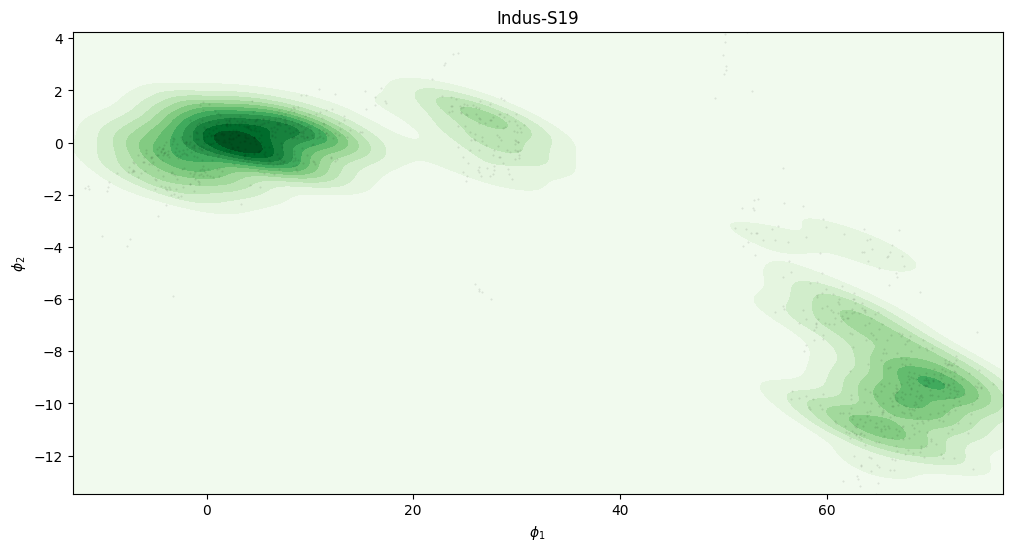

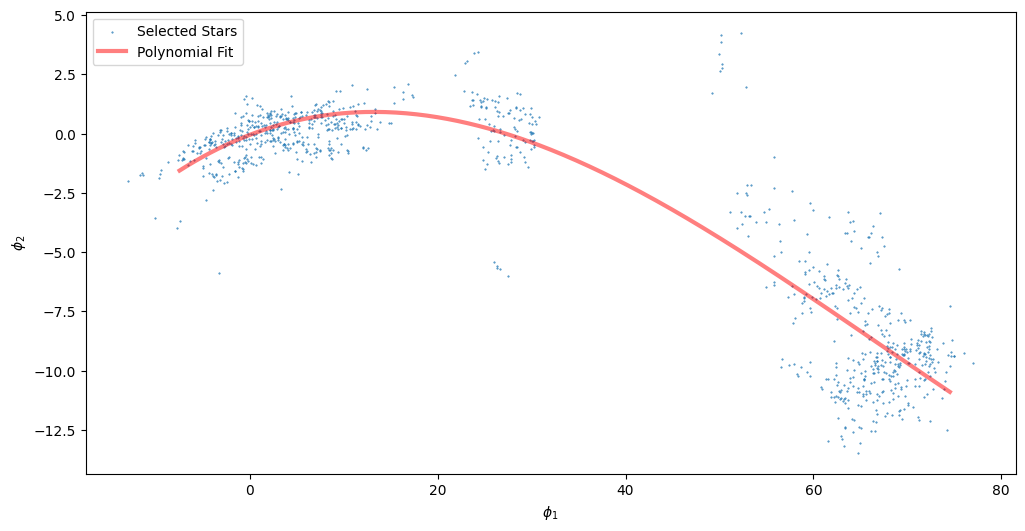

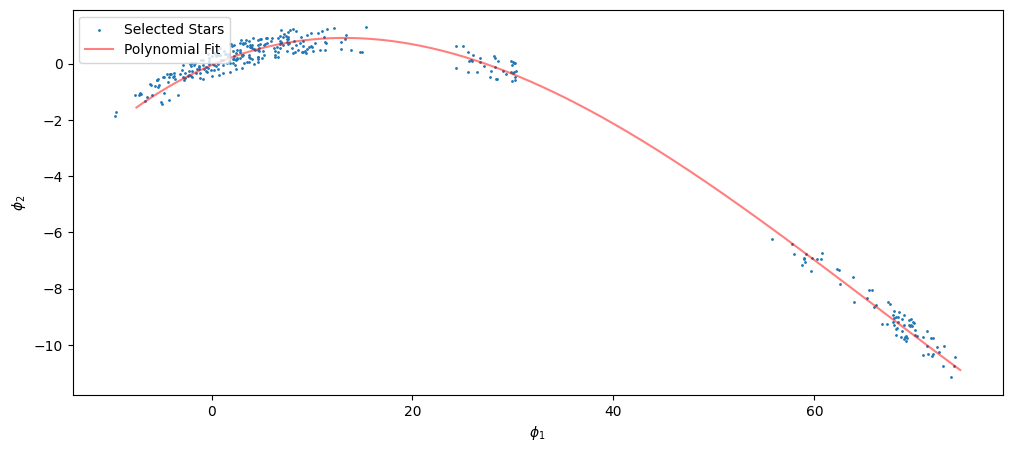

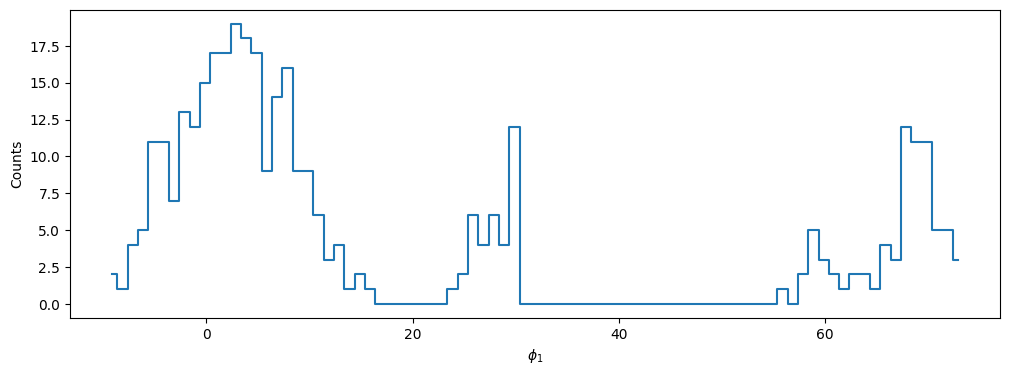

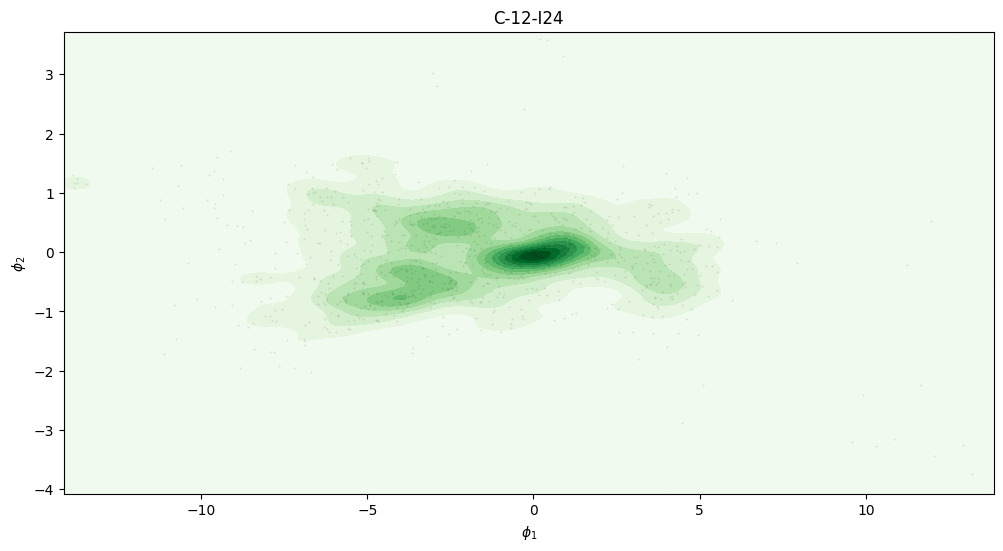

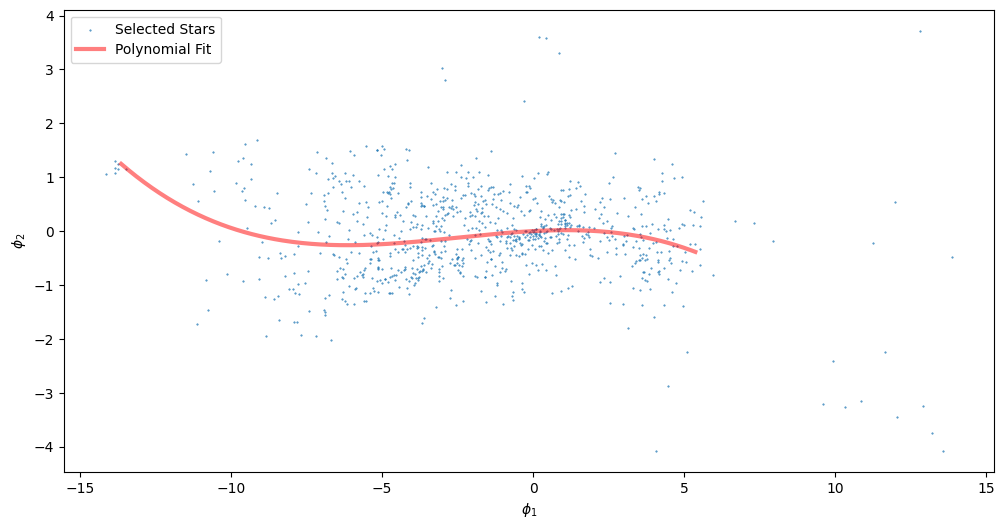

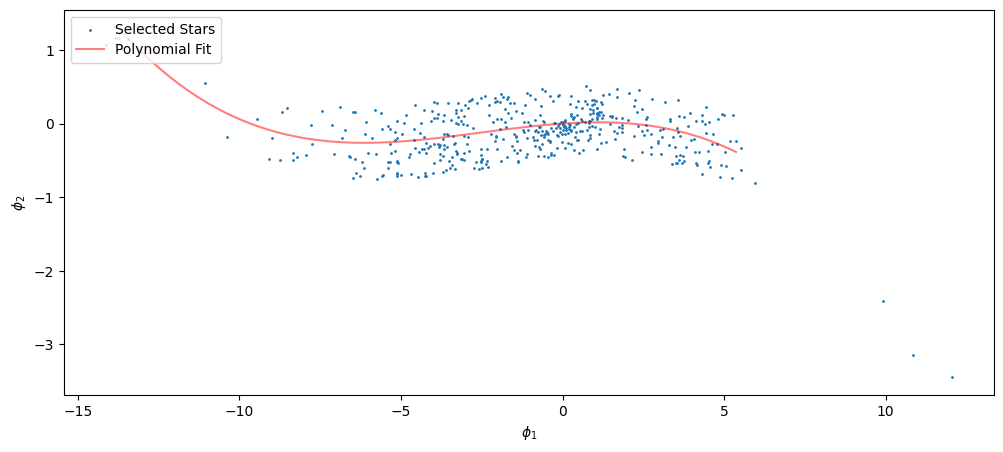

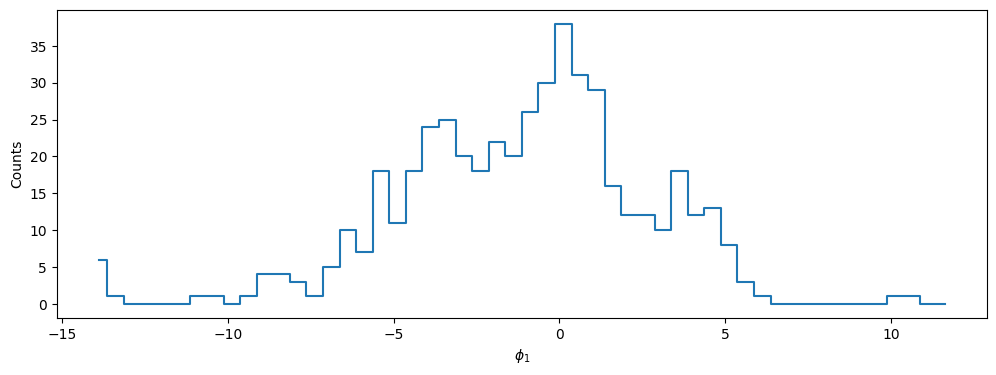

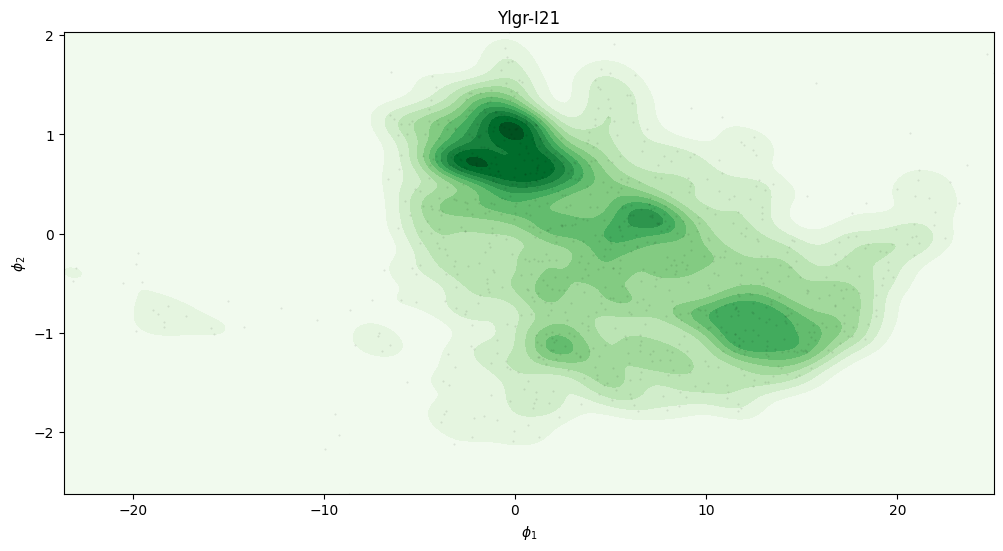

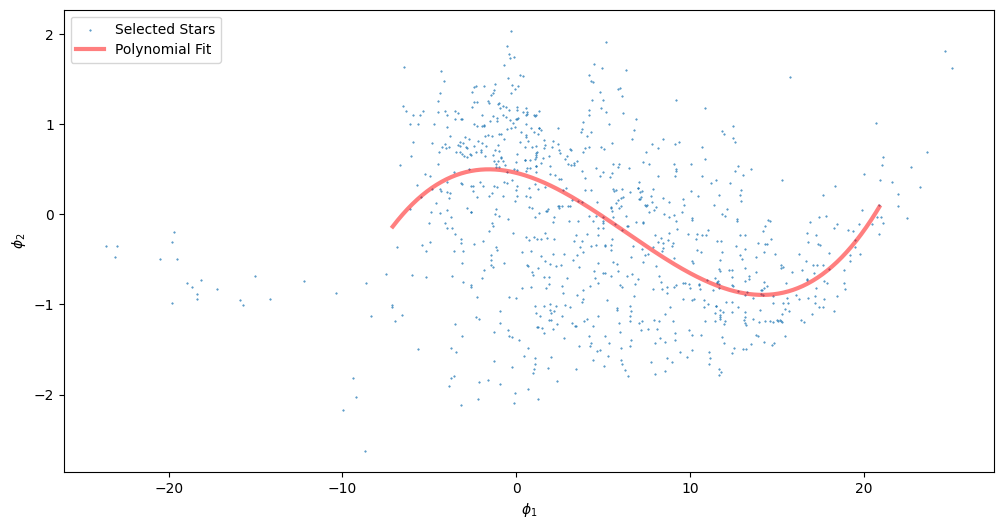

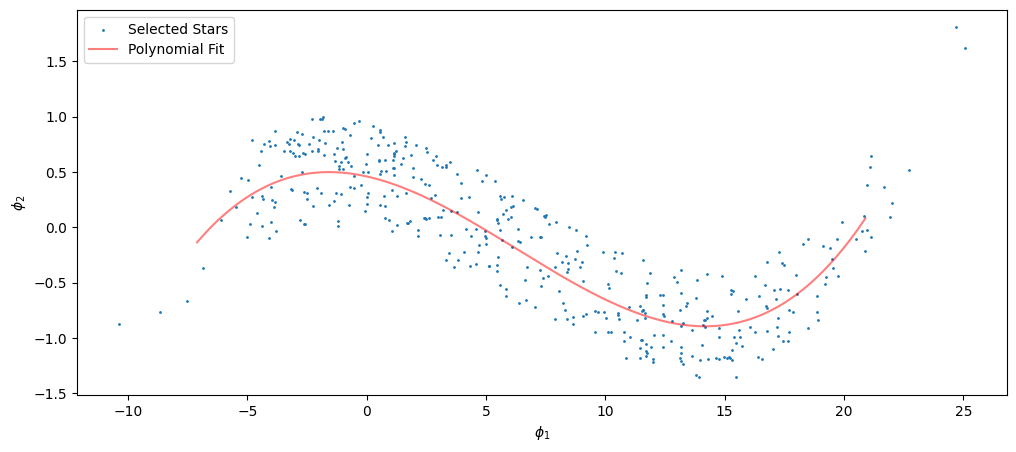

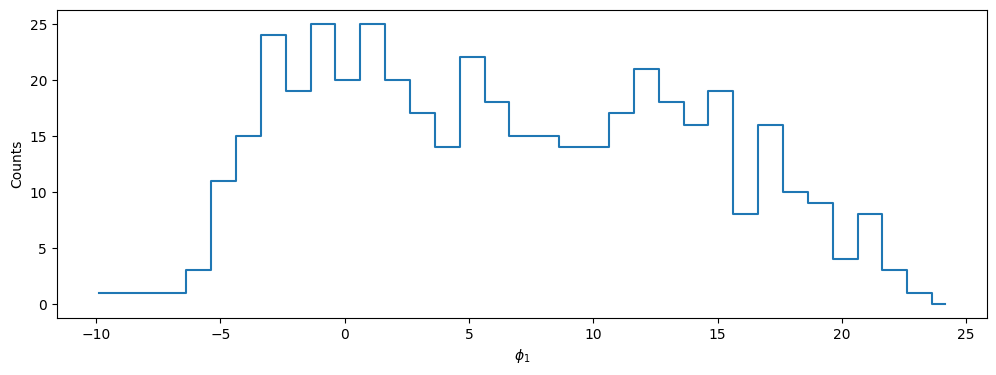

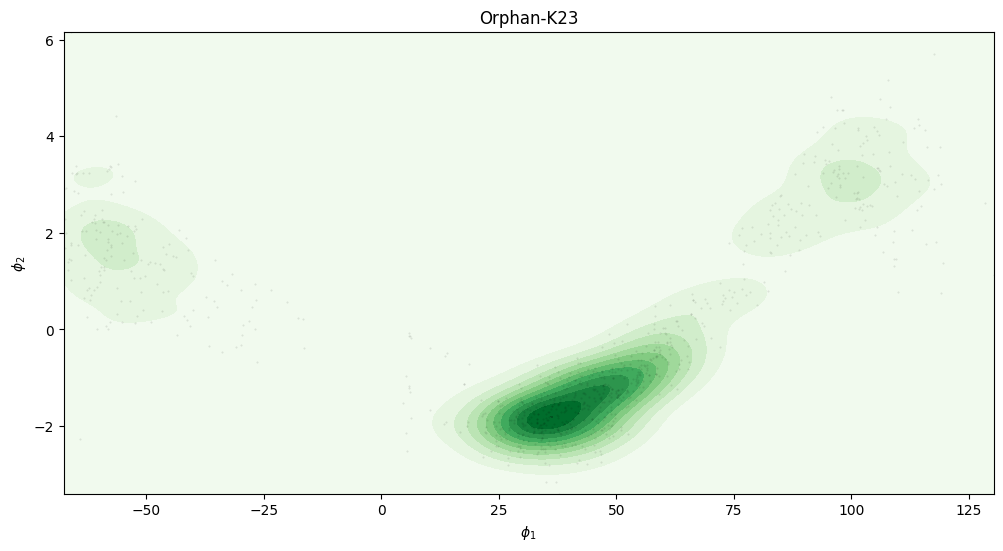

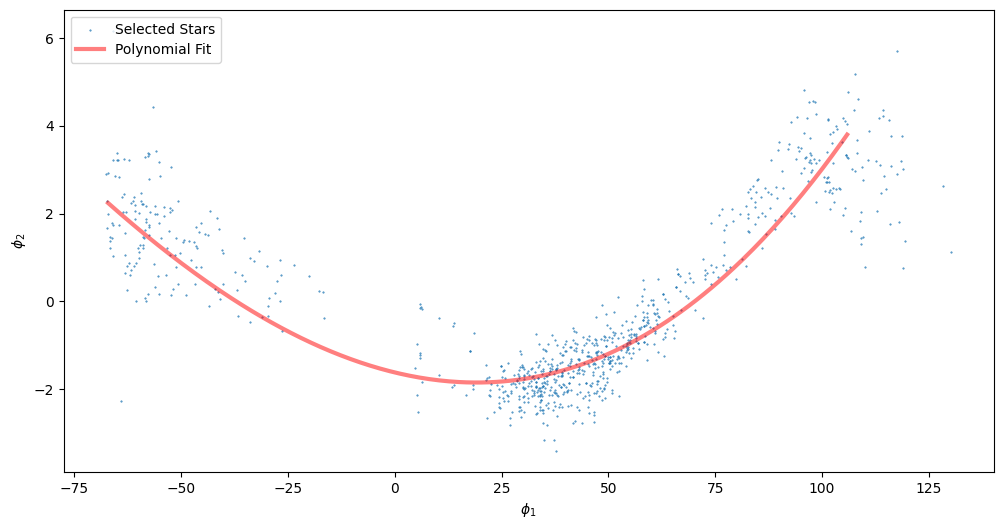

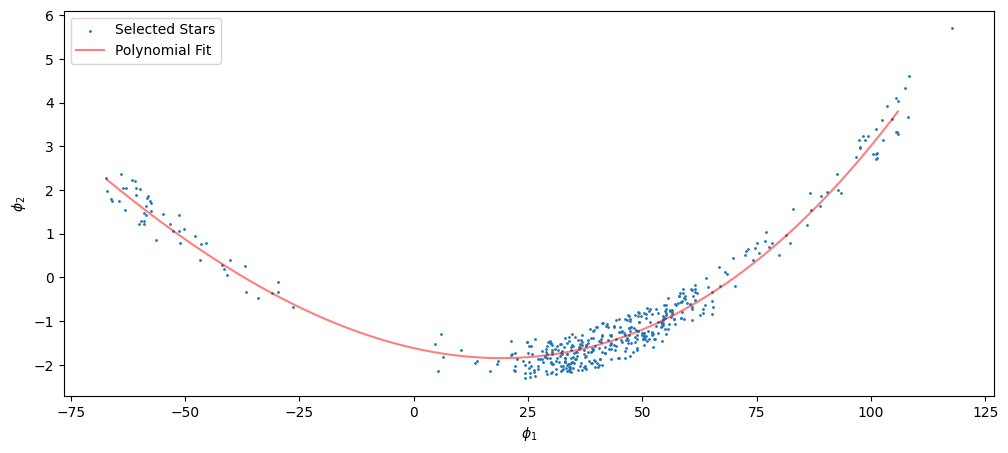

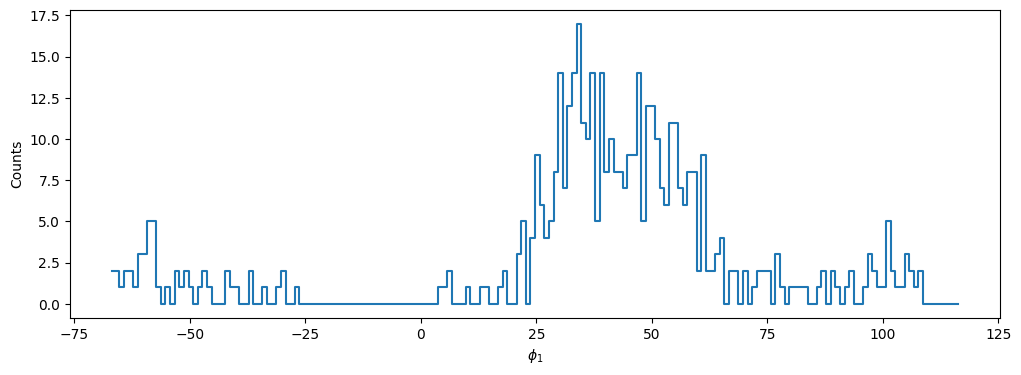

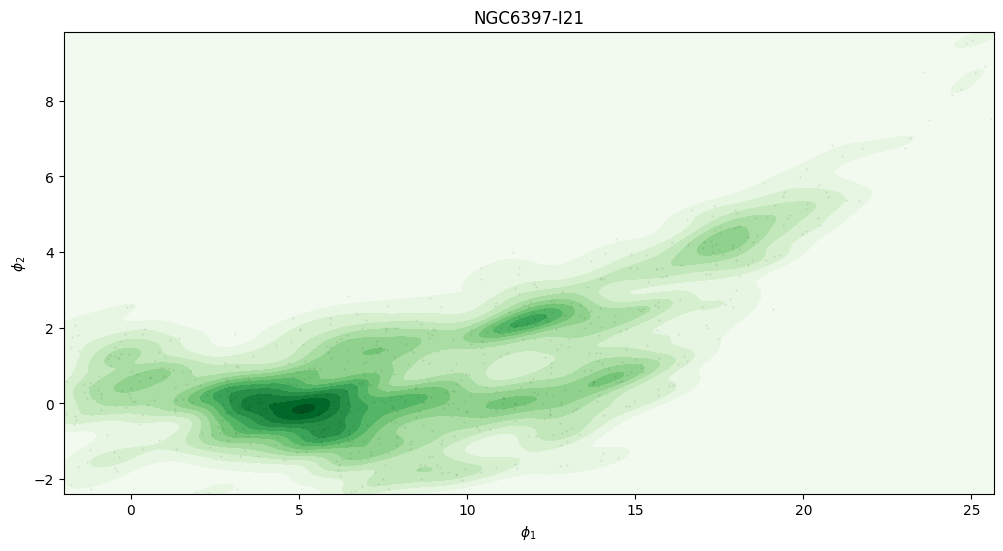

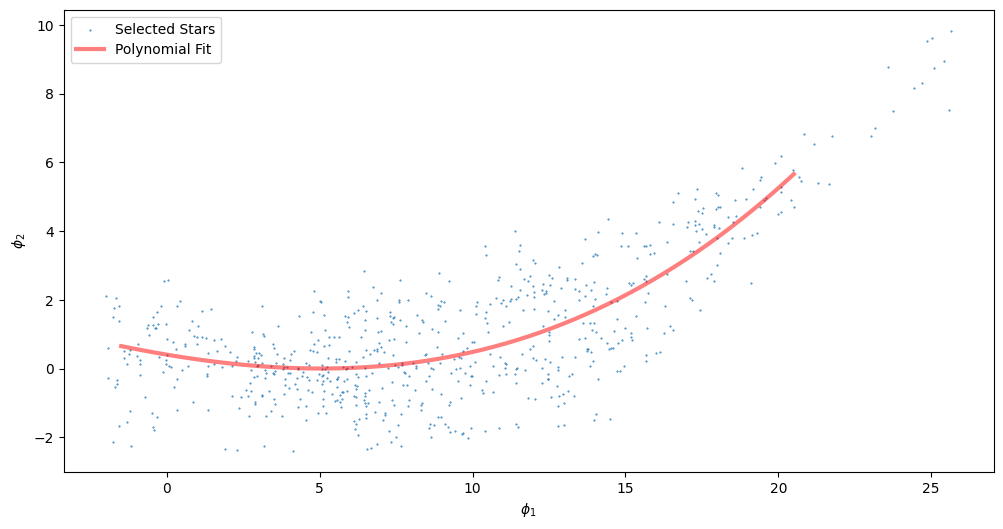

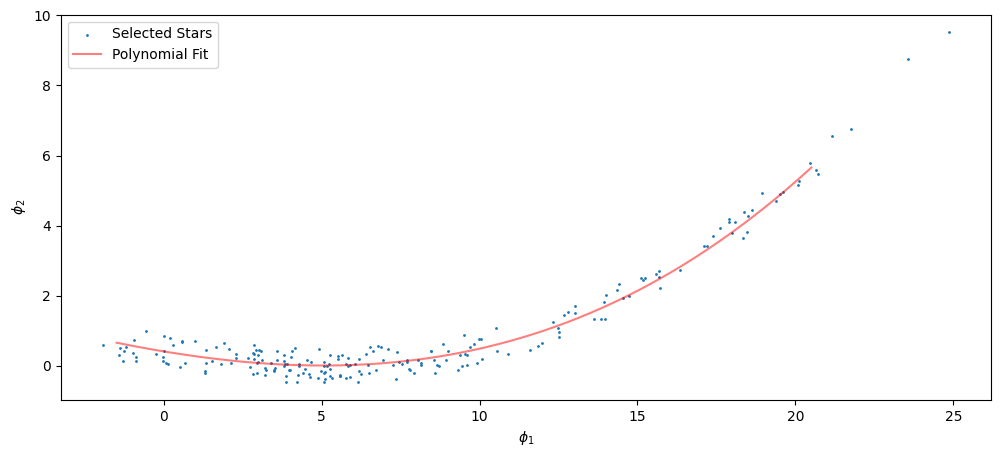

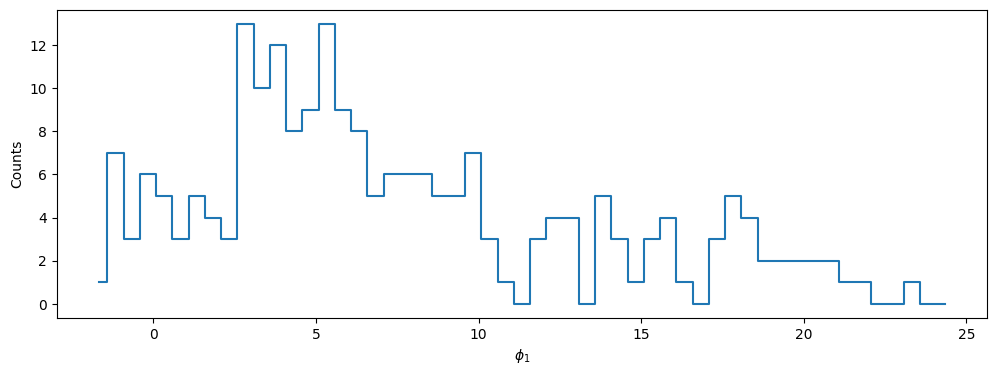

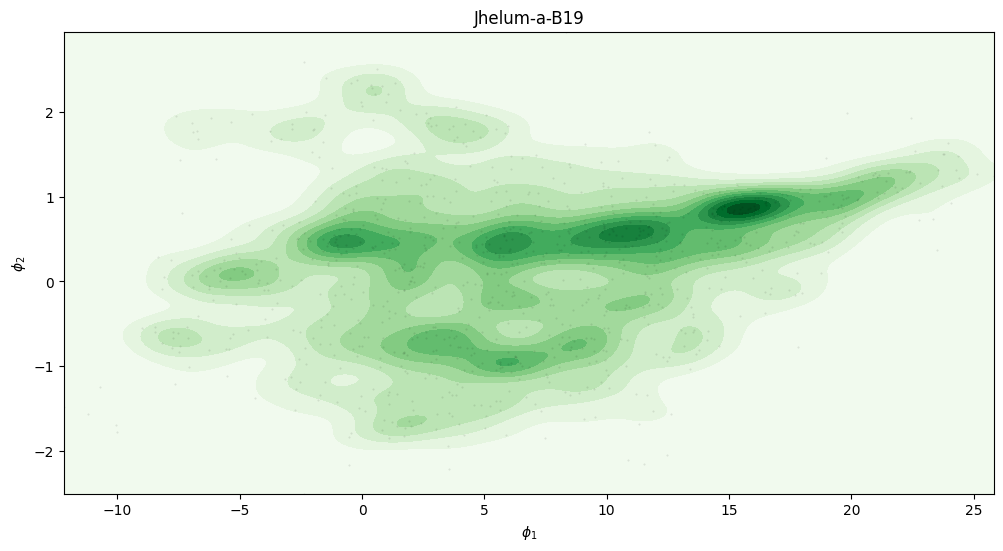

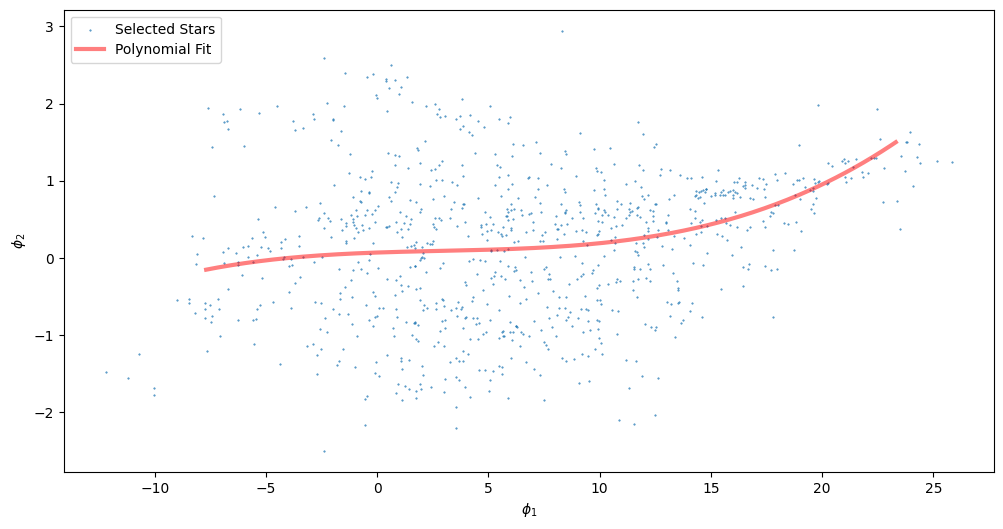

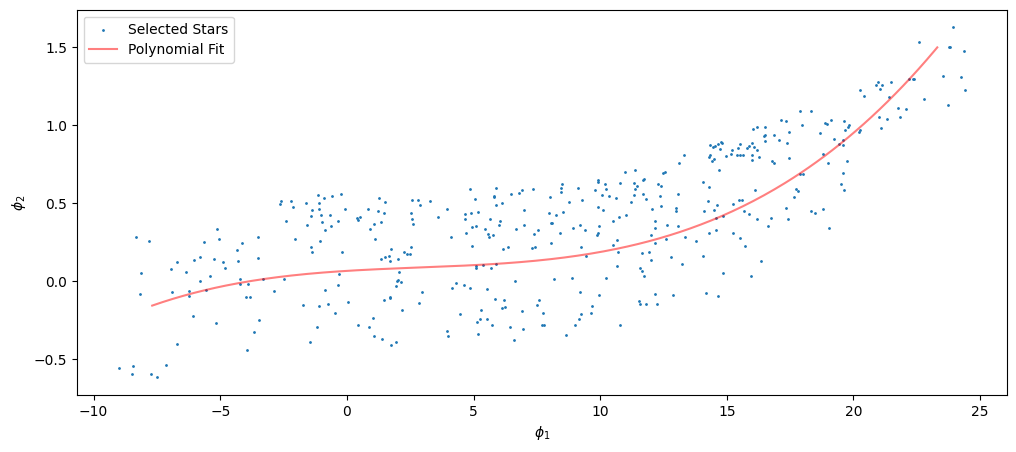

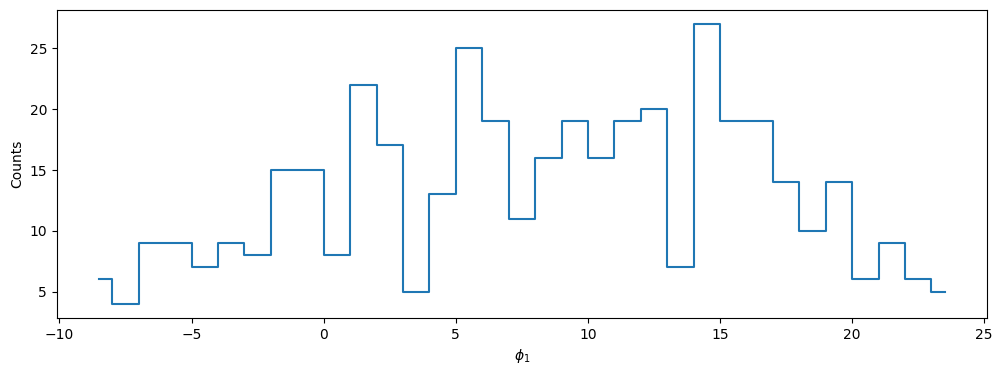

In [ ]:
for i in stream_ids:


  graph(dfs[i], i)